In [ ]:
import scanpy as sc 
adata = sc.read_h5ad("/home/peigao/workspace/scRNA_pipeline/my_pipeline/data/processed/merged.h5ad")
# adata_aml = adata[adata.obs["category"].isin([1])].copy() ## 1 only RR 0 onlyND
# adata_aml
adata.obs = adata.obs.rename(columns={"patient": "individual"})

/home/peigao/miniforge3/envs/scRNA/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [2]:
import pandas as pd

# 统计数量
ct = pd.crosstab(
    adata.obs["sample"],
    adata.obs["celltype"]
)

# 转成比例（按行归一化 = 每个 sample 内部）
ct_ratio = ct.div(ct.sum(axis=1), axis=0)

print(ct_ratio)

celltype      B intermediate   B naive  CD8 Naive T cells       GMP        NK  \
sample                                                                          
MR1_0               0.138431  0.147451           0.088824  0.182941  0.112745   
MR1_80              0.122922  0.267060           0.075022  0.015967  0.398294   
MV4_11              0.208645  0.202775           0.125934  0.082177  0.189434   
MV4_TP53fs_2        0.002840  0.005523           0.003629  0.623008  0.004103   

celltype      Plasmablast   Unknown  
sample                               
MR1_0            0.082353  0.247255  
MR1_80           0.078959  0.041776  
MV4_11           0.076841  0.114194  
MV4_TP53fs_2     0.004103  0.356793  


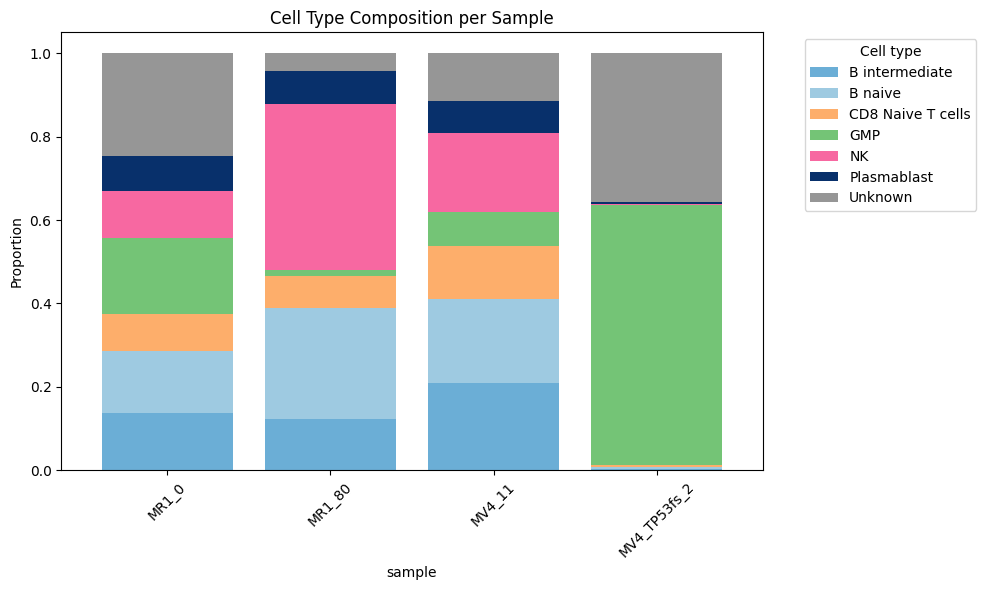

In [8]:
import matplotlib.pyplot as plt
from my_pipeline.src.annotation import celltype_colors_dict 
# ===== 数据 =====
df = ct_ratio.copy().fillna(0)

# 🔥 保证顺序和 adata 一致（非常关键）
celltypes = adata.obs["celltype"].cat.categories

# 只保留存在的列（防止有缺失）
celltypes = [ct for ct in celltypes if ct in df.columns]
df = df[celltypes]

# ===== 颜色映射 =====
colors = [
    celltype_colors_dict.get(ct, "#999999")
    for ct in celltypes
]

# ===== 画图 =====
fig, ax = plt.subplots(figsize=(10, 6))

df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.8
)

# ===== 美化 =====
ax.set_ylabel("Proportion")
ax.set_title("Cell Type Composition per Sample")
ax.set_xticklabels(df.index, rotation=45)

# 图例放右边
ax.legend(
    title="Cell type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()